# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

## 📉 Compare Training Loss

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

TF Version: 2.20.0
Total vocabulary size: 67
Running training routines...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Finished RNN.
Finished LSTM.
Finished GRU.
Graph exported to loss_curves.png


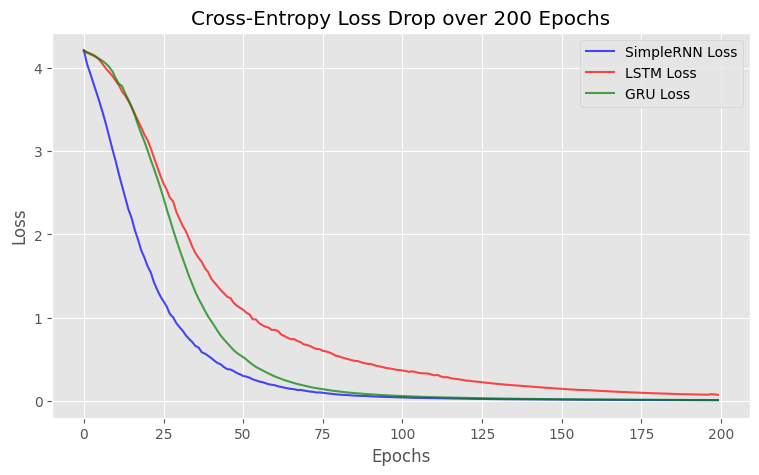


--- 10-Word Generations ---
RNN Out  -> artificial intelligence is rapidly evolving and changing the way we interact with
LSTM Out -> artificial intelligence is rapidly evolving and changing the way we interact with
GRU Out  -> artificial intelligence is rapidly evolving and changing the way we interact with


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Keras components
from keras.models import Sequential
from keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences

print(f"TF Version: {tf.__version__}")

# Custom text data for training
raw_text_data = [
    "artificial intelligence is rapidly evolving and changing the way we interact with technology",
    "natural language processing enables machines to understand and generate human language",
    "deep learning models like recurrent neural networks are designed for sequential data analysis",
    "long short term memory networks solve the vanishing gradient problem in standard recurrent networks",
    "gated recurrent units offer a simplified architecture with performance comparable to complex memory models",
    "generative ai can create novel text images and music based on learned patterns"
]
text_corpus = "\n".join(raw_text_data)

# Setup tokenizer
tok = Tokenizer()
tok.fit_on_texts([text_corpus])
vocab_size = len(tok.word_index) + 1
print(f"Total vocabulary size: {vocab_size}")

# Build the n-grams
ngrams = []
for sent in text_corpus.split('\n'):
    if sent.strip() == "": continue
    tokens = tok.texts_to_sequences([sent])[0]

    # Create the sliding window combos
    for idx in range(1, len(tokens)):
        ngrams.append(tokens[:idx+1])

# Pad out sequences to match lengths
max_seq_length = max([len(seq) for seq in ngrams])
padded_seqs = pad_sequences(ngrams, maxlen=max_seq_length, padding='pre')

X_train = padded_seqs[:, :-1]
y_train = padded_seqs[:, -1]

# Model settings
emb_dim = 128
h_units = 128

# Helper function to generate identical models with different recurrent layers
def build_seq_model(layer_type):
    mdl = Sequential()
    mdl.add(Embedding(vocab_size, emb_dim, input_length=max_seq_length-1))

    if layer_type == 'rnn':
        mdl.add(SimpleRNN(h_units))
    elif layer_type == 'lstm':
        mdl.add(LSTM(h_units))
    elif layer_type == 'gru':
        mdl.add(GRU(h_units))

    mdl.add(Dense(vocab_size, activation='softmax'))
    mdl.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return mdl

# Initialize the 3 requested models
model_rnn = build_seq_model('rnn')
model_lstm = build_seq_model('lstm')
model_gru = build_seq_model('gru')

train_epochs = 200

# Run training
print("Running training routines...")
hist_rnn = model_rnn.fit(X_train, y_train, epochs=train_epochs, verbose=0)
print("Finished RNN.")
hist_lstm = model_lstm.fit(X_train, y_train, epochs=train_epochs, verbose=0)
print("Finished LSTM.")
hist_gru = model_gru.fit(X_train, y_train, epochs=train_epochs, verbose=0)
print("Finished GRU.")

# Plot the training results
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(hist_rnn.history['loss'], label='SimpleRNN Loss', color='blue', alpha=0.7)
ax.plot(hist_lstm.history['loss'], label='LSTM Loss', color='red', alpha=0.7)
ax.plot(hist_gru.history['loss'], label='GRU Loss', color='green', alpha=0.7)

ax.set_title("Cross-Entropy Loss Drop over 200 Epochs")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.legend()

plt.savefig('loss_curves.png')
print("Graph exported to loss_curves.png")
plt.show()

# Text generation logic
def make_text(mdl, start_phrase, num_words):
    current_phrase = start_phrase
    for _ in range(num_words):
        encoded = tok.texts_to_sequences([current_phrase])[0]
        encoded = pad_sequences([encoded], maxlen=max_seq_length-1, padding='pre')

        preds = mdl.predict(encoded, verbose=0)
        next_word_idx = np.argmax(preds, axis=-1)[0]

        # Dictionary reverse lookup
        found_word = ""
        for w, i in tok.word_index.items():
            if i == next_word_idx:
                found_word = w
                break
        current_phrase += f" {found_word}"

    return current_phrase

# Generation
print("\n--- 10-Word Generations ---")
seed = "artificial intelligence"

print("RNN Out  ->", make_text(model_rnn, seed, 10))
print("LSTM Out ->", make_text(model_lstm, seed, 10))
print("GRU Out  ->", make_text(model_gru, seed, 10))

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**